# Module 2 — Classification, Regression & Explainability
**Course:** Data Mining 2 | **Dataset:** Child Mind Institute – Problematic Internet Use

This notebook covers three tasks:
1. **Advanced Classification** — 6 classifier families with hyperparameter tuning (LR, SVM, NN/MLP, Bagging, Random Forest, AdaBoost) + ordinal XGBoost
2. **Advanced Regression** — XGBoost Regressor and Random Forest Regressor on CGAS score
3. **Explainability** — SHAP analysis on the best classification model

---
> **Prerequisite:** Run `01_outlier_imbalance.ipynb` first (needs `X_train_clean.csv`).

## 2.0 — Setup: Imports and Paths

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, time

# ── Classification ───────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                               AdaBoostClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, roc_auc_score)
from xgboost import XGBClassifier

# ── Regression ───────────────────────────────────────────────────────────────
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Explainability ───────────────────────────────────────────────────────────
import shap

RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 110
OUT_DIR = '../outputs/'

# ── Load data ─────────────────────────────────────────────────────────────────
X_train = pd.read_csv(OUT_DIR + 'X_train_clean.csv')
y_train = pd.read_csv(OUT_DIR + 'y_train_clean.csv')['sii'].astype(int)
X_test  = pd.read_csv(OUT_DIR + 'X_test_processed.csv')
y_test  = pd.read_csv(OUT_DIR + 'y_test.csv')['sii'].astype(int)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print("Class distribution (train):", y_train.value_counts(normalize=True).sort_index().round(3).to_dict())

Train: (5859, 107)  |  Test: (2115, 107)
Class distribution (train): {0: 0.697, 1: 0.184, 2: 0.108, 3: 0.01}


---
## Part A — Advanced Classification

### Strategy: Ordinal Cumulative Binary Models
Because `sii` is **ordinal** (0 < 1 < 2 < 3), we decompose the problem into three binary thresholds:

| Model | Task | Positive rate (train) |
|-------|------|----------------------|
| M1 | P(sii ≥ 1) | 30.3% |
| M2 | P(sii ≥ 2) | 11.9% |
| M3 | P(sii ≥ 3) | 1.0% |

Predicted probabilities are recombined: **P(sii=k) = P(sii≥k) − P(sii≥k+1)**  
Additional direct 4-class models (SVM, NN, Bagging, RF, AdaBoost) use `class_weight='balanced'`.

## 2.1 — Standardise Features

In [2]:
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print("Scaling done.")

Scaling done.


## 2.2 — Ordinal Models: Logistic Regression Baseline

In [3]:
thresholds = [1, 2, 3]
y_train_bin = {k: (y_train >= k).astype(int) for k in thresholds}
y_test_bin  = {k: (y_test  >= k).astype(int) for k in thresholds}

lr_models = {}
proba_lr  = {}

for k in thresholds:
    pos = y_train_bin[k].sum(); neg = len(y_train_bin[k]) - pos
    print(f"sii >= {k}: positive rate = {pos/(pos+neg)*100:.1f}%", end="  |  ")
    lr = LogisticRegression(max_iter=2000, class_weight='balanced',
                             C=1.0, random_state=RANDOM_STATE)
    lr.fit(X_train_s, y_train_bin[k])
    lr_models[k] = lr
    proba_lr[k]  = lr.predict_proba(X_test_s)[:, 1]
    auc = roc_auc_score(y_test_bin[k], proba_lr[k])
    print(f"LogReg AUC = {auc:.3f}")

sii >= 1: positive rate = 30.3%  |  LogReg AUC = 0.703
sii >= 2: positive rate = 11.9%  |  LogReg AUC = 0.732
sii >= 3: positive rate = 1.0%  |  LogReg AUC = 0.732


## 2.3 — Ordinal Models: XGBoost

In [4]:
xgb_models = {}
proba_xgb  = {}

for k in thresholds:
    pos = y_train_bin[k].sum(); neg = len(y_train_bin[k]) - pos
    spw = neg / pos  # scale_pos_weight

    xgb = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.5, reg_alpha=0.1,
        scale_pos_weight=spw,
        eval_metric='logloss', random_state=RANDOM_STATE
    )
    xgb.fit(X_train, y_train_bin[k])
    xgb_models[k] = xgb
    proba_xgb[k]  = xgb.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test_bin[k], proba_xgb[k])
    print(f"sii >= {k}: scale_pos_weight={spw:.1f}  |  XGBoost AUC = {auc:.3f}")

sii >= 1: scale_pos_weight=2.3  |  XGBoost AUC = 0.740
sii >= 2: scale_pos_weight=7.4  |  XGBoost AUC = 0.750
sii >= 3: scale_pos_weight=96.7  |  XGBoost AUC = 0.763


## 2.4 — Combine Ordinal Probabilities → Final Prediction

In [5]:
def combine_ordinal(proba_dict):
    """P(sii=k) = P(sii>=k) - P(sii>=k+1), clip, renormalise, argmax."""
    p1, p2, p3 = proba_dict[1], proba_dict[2], proba_dict[3]
    p_cls = np.vstack([
        1 - p1,
        np.clip(p1 - p2, 0, None),
        np.clip(p2 - p3, 0, None),
        p3
    ]).T
    p_cls /= p_cls.sum(axis=1, keepdims=True)
    return p_cls, p_cls.argmax(axis=1)

_, pred_lr  = combine_ordinal(proba_lr)
_, pred_xgb = combine_ordinal(proba_xgb)

print("Logistic Regression (ordinal):")
print(classification_report(y_test, pred_lr, digits=2, zero_division=0))
print("XGBoost (ordinal):")
print(classification_report(y_test, pred_xgb, digits=2, zero_division=0))

np.save(OUT_DIR + 'pred_lr.npy',  pred_lr)
np.save(OUT_DIR + 'pred_xgb.npy', pred_xgb)
joblib.dump(xgb_models, OUT_DIR + 'xgb_models.pkl')
joblib.dump(scaler,     OUT_DIR + 'scaler.pkl')

Logistic Regression (ordinal):
              precision    recall  f1-score   support

           0       0.79      0.69      0.74      1458
           1       0.12      0.00      0.00       397
           2       0.19      0.36      0.25       238
           3       0.02      0.41      0.04        22

    accuracy                           0.52      2115
   macro avg       0.28      0.36      0.26      2115
weighted avg       0.59      0.52      0.54      2115

XGBoost (ordinal):
              precision    recall  f1-score   support

           0       0.78      0.79      0.79      1458
           1       0.31      0.06      0.10       397
           2       0.25      0.55      0.35       238
           3       0.05      0.05      0.05        22

    accuracy                           0.62      2115
   macro avg       0.35      0.36      0.32      2115
weighted avg       0.62      0.62      0.60      2115



['../outputs/scaler.pkl']

## 2.5 — ROC Curves per Threshold (Figure 2.1)

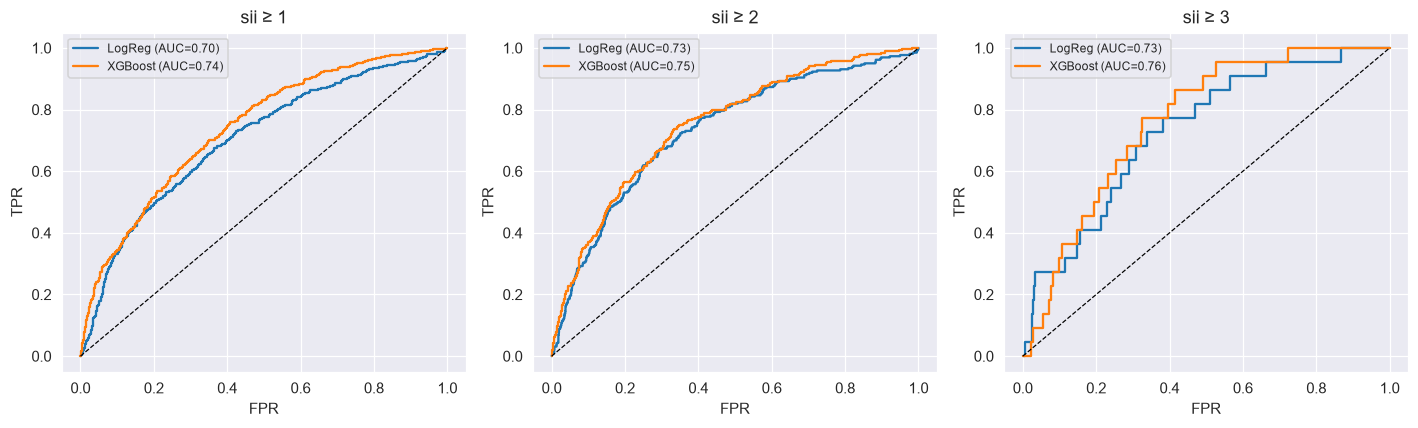

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i, k in enumerate(thresholds):
    fpr_lr,  tpr_lr,  _ = roc_curve(y_test_bin[k], proba_lr[k])
    fpr_xgb, tpr_xgb, _ = roc_curve(y_test_bin[k], proba_xgb[k])
    auc_lr  = roc_auc_score(y_test_bin[k], proba_lr[k])
    auc_xgb = roc_auc_score(y_test_bin[k], proba_xgb[k])
    axes[i].plot(fpr_lr,  tpr_lr,  label=f'LogReg (AUC={auc_lr:.2f})')
    axes[i].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_xgb:.2f})')
    axes[i].plot([0,1],[0,1],'k--', linewidth=0.8)
    axes[i].set_title(f'sii ≥ {k}')
    axes[i].set_xlabel('FPR'); axes[i].set_ylabel('TPR')
    axes[i].legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig10_roc_thresholds.png', dpi=110); plt.show()

## 2.6 — SVM with Hyperparameter Tuning

In [7]:
t0 = time.time()
param_dist_svm = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
search_svm = RandomizedSearchCV(
    SVC(class_weight='balanced', probability=True, random_state=RANDOM_STATE),
    param_dist_svm, n_iter=4, cv=2, scoring='f1_macro',
    random_state=RANDOM_STATE, n_jobs=-1
)
search_svm.fit(X_train_s, y_train)
print(f"SVM done in {time.time()-t0:.1f}s  |  Best: {search_svm.best_params_}  |  CV F1: {search_svm.best_score_:.3f}")

pred_svm  = search_svm.best_estimator_.predict(X_test_s)
proba_svm = search_svm.best_estimator_.predict_proba(X_test_s)
print(classification_report(y_test, pred_svm, digits=2, zero_division=0))

joblib.dump({'model': search_svm.best_estimator_, 'pred': pred_svm,
             'proba': proba_svm, 'best_params': search_svm.best_params_,
             'cv_f1': search_svm.best_score_}, OUT_DIR + 'm2_svm.pkl')

SVM done in 69.8s  |  Best: {'kernel': 'linear', 'C': 1}  |  CV F1: 0.316
              precision    recall  f1-score   support

           0       0.81      0.56      0.66      1458
           1       0.28      0.33      0.30       397
           2       0.22      0.34      0.27       238
           3       0.03      0.32      0.05        22

    accuracy                           0.49      2115
   macro avg       0.33      0.39      0.32      2115
weighted avg       0.64      0.49      0.54      2115



['../outputs/m2_svm.pkl']

## 2.7 — Neural Network (MLP) with Hyperparameter Tuning

In [8]:
t0 = time.time()
param_dist_mlp = {
    'hidden_layer_sizes': [(64,), (128, 64), (128, 64, 32)],
    'alpha':              [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01],
}
search_mlp = RandomizedSearchCV(
    MLPClassifier(max_iter=300, early_stopping=True, random_state=RANDOM_STATE),
    param_dist_mlp, n_iter=5, cv=2, scoring='f1_macro',
    random_state=RANDOM_STATE, n_jobs=-1
)
search_mlp.fit(X_train_s, y_train)
print(f"MLP done in {time.time()-t0:.1f}s  |  Best: {search_mlp.best_params_}  |  CV F1: {search_mlp.best_score_:.3f}")

pred_mlp  = search_mlp.best_estimator_.predict(X_test_s)
proba_mlp = search_mlp.best_estimator_.predict_proba(X_test_s)
print(classification_report(y_test, pred_mlp, digits=2, zero_division=0))

joblib.dump({'model': search_mlp.best_estimator_, 'pred': pred_mlp, 'proba': proba_mlp,
             'best_params': search_mlp.best_params_, 'cv_f1': search_mlp.best_score_,
             'loss_curve': search_mlp.best_estimator_.loss_curve_}, OUT_DIR + 'm2_mlp.pkl')

MLP done in 1.3s  |  Best: {'learning_rate_init': 0.01, 'hidden_layer_sizes': (64,), 'alpha': 0.0001}  |  CV F1: 0.305
              precision    recall  f1-score   support

           0       0.73      0.92      0.81      1458
           1       0.35      0.11      0.16       397
           2       0.29      0.19      0.23       238
           3       0.00      0.00      0.00        22

    accuracy                           0.67      2115
   macro avg       0.34      0.30      0.30      2115
weighted avg       0.60      0.67      0.62      2115



['../outputs/m2_mlp.pkl']

## 2.8 — MLP Loss Curve (Figure 2.2)

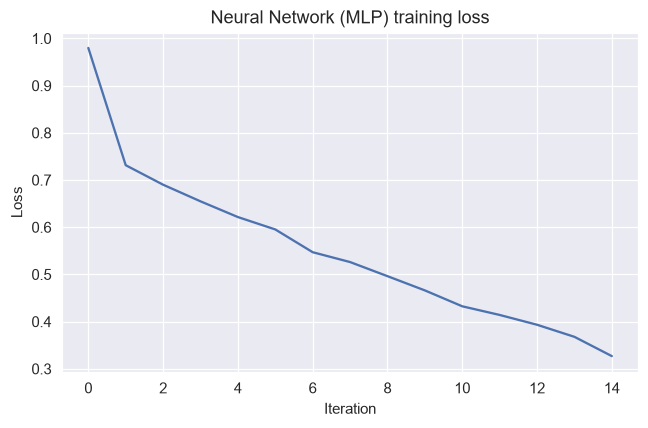

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(search_mlp.best_estimator_.loss_curve_, color='#4C72B0')
ax.set_xlabel('Iteration'); ax.set_ylabel('Loss')
ax.set_title('Neural Network (MLP) training loss')
plt.tight_layout(); plt.savefig(OUT_DIR + 'fig24_mlp_loss_curve.png', dpi=110); plt.show()

## 2.9 — Bagging Classifier

In [10]:
t0 = time.time()
param_dist_bag = {
    'n_estimators': [50, 100, 200],
    'max_samples':  [0.5, 0.7, 1.0],
    'max_features': [0.5, 0.7, 1.0],
}
search_bag = RandomizedSearchCV(
    BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                      random_state=RANDOM_STATE), random_state=RANDOM_STATE),
    param_dist_bag, n_iter=6, cv=2, scoring='f1_macro',
    random_state=RANDOM_STATE, n_jobs=-1
)
search_bag.fit(X_train, y_train)
print(f"Bagging done in {time.time()-t0:.1f}s  |  Best: {search_bag.best_params_}  |  CV F1: {search_bag.best_score_:.3f}")

pred_bag  = search_bag.best_estimator_.predict(X_test)
proba_bag = search_bag.best_estimator_.predict_proba(X_test)
print(classification_report(y_test, pred_bag, digits=2, zero_division=0))

joblib.dump({'model': search_bag.best_estimator_, 'pred': pred_bag, 'proba': proba_bag,
             'best_params': search_bag.best_params_, 'cv_f1': search_bag.best_score_},
            OUT_DIR + 'm2_bagging.pkl')

Bagging done in 16.0s  |  Best: {'n_estimators': 50, 'max_samples': 0.7, 'max_features': 1.0}  |  CV F1: 0.234
              precision    recall  f1-score   support

           0       0.70      0.99      0.82      1458
           1       0.37      0.04      0.06       397
           2       0.33      0.03      0.05       238
           3       0.00      0.00      0.00        22

    accuracy                           0.69      2115
   macro avg       0.35      0.26      0.23      2115
weighted avg       0.59      0.69      0.58      2115



['../outputs/m2_bagging.pkl']

## 2.10 — Random Forest Classifier

In [11]:
t0 = time.time()
param_dist_rf = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [10, 20, 40, None],
    'max_features':     [0.3, 0.5, 0.7, 'sqrt'],
    'min_samples_leaf': [1, 2, 5],
}
search_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    param_dist_rf, n_iter=8, cv=2, scoring='f1_macro',
    random_state=RANDOM_STATE, n_jobs=-1
)
search_rf.fit(X_train, y_train)
print(f"RF done in {time.time()-t0:.1f}s  |  Best: {search_rf.best_params_}  |  CV F1: {search_rf.best_score_:.3f}")

pred_rf  = search_rf.best_estimator_.predict(X_test)
proba_rf = search_rf.best_estimator_.predict_proba(X_test)
print(classification_report(y_test, pred_rf, digits=2, zero_division=0))

joblib.dump({'model': search_rf.best_estimator_, 'pred': pred_rf, 'proba': proba_rf,
             'best_params': search_rf.best_params_, 'cv_f1': search_rf.best_score_},
            OUT_DIR + 'm2_rf.pkl')

RF done in 36.6s  |  Best: {'n_estimators': 200, 'min_samples_leaf': 5, 'max_features': 0.7, 'max_depth': 40}  |  CV F1: 0.319
              precision    recall  f1-score   support

           0       0.76      0.88      0.82      1458
           1       0.34      0.20      0.25       397
           2       0.33      0.27      0.30       238
           3       0.00      0.00      0.00        22

    accuracy                           0.68      2115
   macro avg       0.36      0.34      0.34      2115
weighted avg       0.63      0.68      0.64      2115



['../outputs/m2_rf.pkl']

## 2.11 — AdaBoost Classifier

In [12]:
t0 = time.time()
param_dist_ada = {
    'n_estimators':          [50, 100, 200],
    'learning_rate':         [0.5, 1.0, 1.5],
    'estimator__max_depth':  [1, 2, 3],
}
search_ada = RandomizedSearchCV(
    AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
                       random_state=RANDOM_STATE),
    param_dist_ada, n_iter=6, cv=2, scoring='f1_macro',
    random_state=RANDOM_STATE, n_jobs=-1
)
search_ada.fit(X_train, y_train)
print(f"AdaBoost done in {time.time()-t0:.1f}s  |  Best: {search_ada.best_params_}  |  CV F1: {search_ada.best_score_:.3f}")

pred_ada  = search_ada.best_estimator_.predict(X_test)
proba_ada = search_ada.best_estimator_.predict_proba(X_test)
print(classification_report(y_test, pred_ada, digits=2, zero_division=0))

joblib.dump({'model': search_ada.best_estimator_, 'pred': pred_ada, 'proba': proba_ada,
             'best_params': search_ada.best_params_, 'cv_f1': search_ada.best_score_},
            OUT_DIR + 'm2_ada.pkl')

AdaBoost done in 8.0s  |  Best: {'n_estimators': 50, 'learning_rate': 1.0, 'estimator__max_depth': 3}  |  CV F1: 0.303
              precision    recall  f1-score   support

           0       0.74      0.88      0.80      1458
           1       0.30      0.19      0.23       397
           2       0.27      0.16      0.20       238
           3       0.00      0.00      0.00        22

    accuracy                           0.66      2115
   macro avg       0.33      0.31      0.31      2115
weighted avg       0.60      0.66      0.62      2115



['../outputs/m2_ada.pkl']

## 2.12 — Full Results Table

In [13]:
models_res = {
    'SVM':          {'pred': pred_svm,  'proba': proba_svm,  'best_params': search_svm.best_params_,  'cv_f1': search_svm.best_score_},
    'Neural Net':   {'pred': pred_mlp,  'proba': proba_mlp,  'best_params': search_mlp.best_params_,  'cv_f1': search_mlp.best_score_},
    'Bagging':      {'pred': pred_bag,  'proba': proba_bag,  'best_params': search_bag.best_params_,  'cv_f1': search_bag.best_score_},
    'Random Forest':{'pred': pred_rf,   'proba': proba_rf,   'best_params': search_rf.best_params_,   'cv_f1': search_rf.best_score_},
    'AdaBoost':     {'pred': pred_ada,  'proba': proba_ada,  'best_params': search_ada.best_params_,  'cv_f1': search_ada.best_score_},
}

rows = []
for name, res in models_res.items():
    rep = classification_report(y_test, res['pred'], output_dict=True, zero_division=0)
    rows.append({
        'Model':         name,
        'Best params':   str(res['best_params']),
        'CV macro-F1':   res['cv_f1'],
        'Accuracy':      rep['accuracy'],
        'Macro F1':      rep['macro avg']['f1-score'],
        'Weighted F1':   rep['weighted avg']['f1-score'],
        'F1 sii=0':      rep.get('0', {}).get('f1-score', 0),
        'F1 sii=1':      rep.get('1', {}).get('f1-score', 0),
        'F1 sii=2':      rep.get('2', {}).get('f1-score', 0),
        'F1 sii=3':      rep.get('3', {}).get('f1-score', 0),
    })

# Add ordinal models
for name, pred in [('LogReg (ordinal)', pred_lr), ('XGBoost (ordinal)', pred_xgb)]:
    rep = classification_report(y_test, pred, output_dict=True, zero_division=0)
    rows.append({
        'Model': name, 'Best params': '-', 'CV macro-F1': None,
        'Accuracy': rep['accuracy'], 'Macro F1': rep['macro avg']['f1-score'],
        'Weighted F1': rep['weighted avg']['f1-score'],
        'F1 sii=0': rep.get('0',{}).get('f1-score',0), 'F1 sii=1': rep.get('1',{}).get('f1-score',0),
        'F1 sii=2': rep.get('2',{}).get('f1-score',0), 'F1 sii=3': rep.get('3',{}).get('f1-score',0),
    })

results_df = pd.DataFrame(rows)
results_df.to_csv(OUT_DIR + 'table_module2_all_results.csv', index=False)
print(results_df[['Model','Accuracy','Macro F1','F1 sii=0','F1 sii=1','F1 sii=2','F1 sii=3']].round(3).to_string(index=False))

            Model  Accuracy  Macro F1  F1 sii=0  F1 sii=1  F1 sii=2  F1 sii=3
              SVM     0.490     0.320     0.662     0.304     0.267     0.049
       Neural Net     0.674     0.301     0.813     0.162     0.231     0.000
          Bagging     0.692     0.233     0.821     0.064     0.047     0.000
    Random Forest     0.675     0.341     0.817     0.249     0.300     0.000
         AdaBoost     0.657     0.308     0.803     0.230     0.201     0.000
 LogReg (ordinal)     0.521     0.259     0.738     0.005     0.250     0.043
XGBoost (ordinal)     0.622     0.320     0.786     0.101     0.346     0.047


## 2.13 — Confusion Matrices (Figure 2.3)

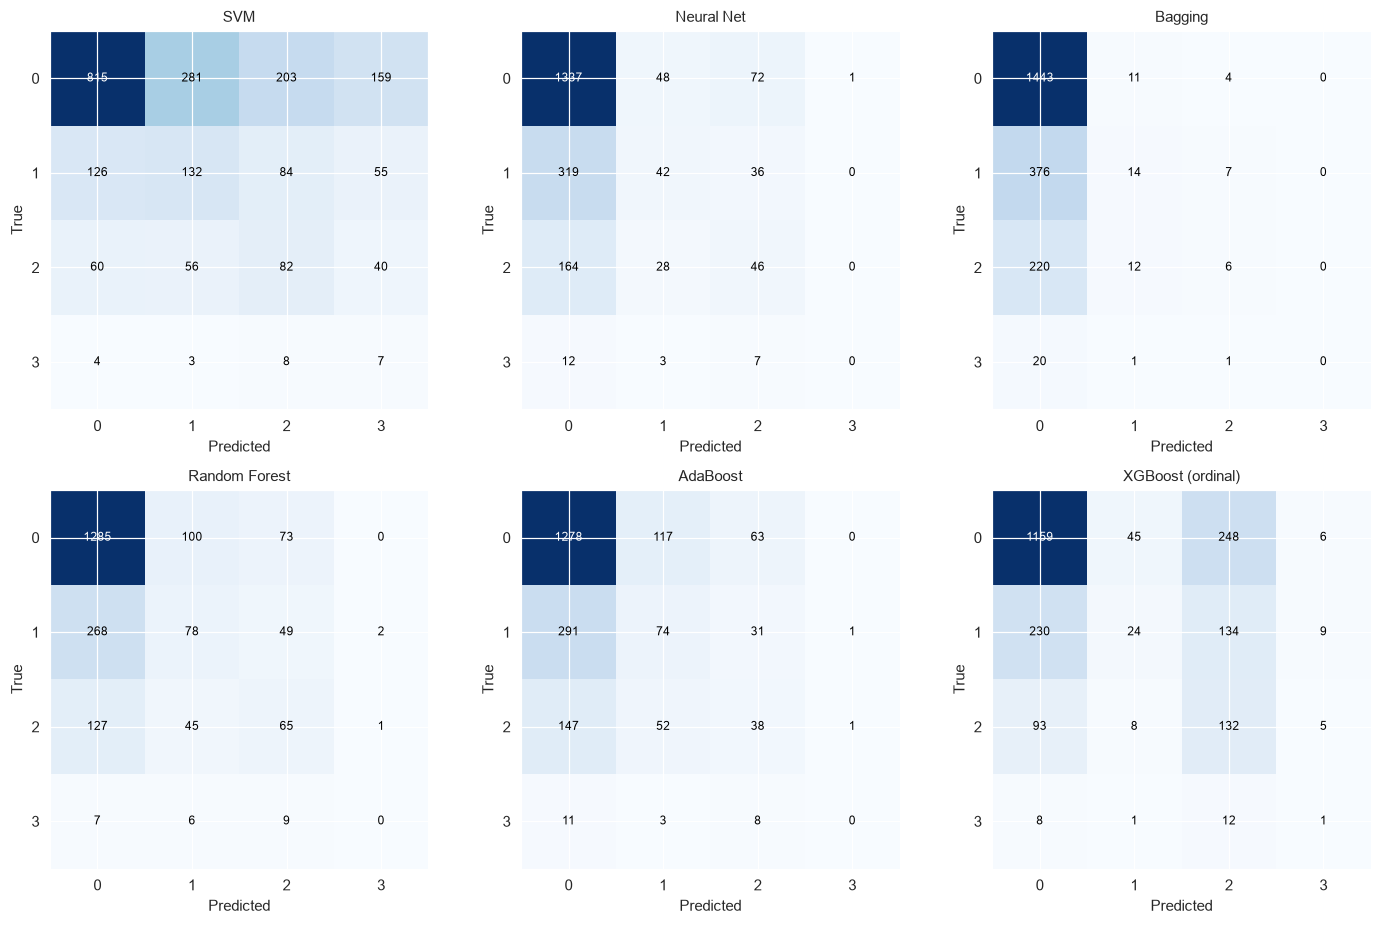

In [14]:
all_preds = {k: v['pred'] for k, v in models_res.items()}
all_preds['XGBoost (ordinal)'] = pred_xgb

fig, axes = plt.subplots(2, 3, figsize=(13, 8.5))
for ax, (name, pred) in zip(axes.flat, all_preds.items()):
    cm = confusion_matrix(y_test, pred, labels=[0,1,2,3])
    ax.imshow(cm, cmap='Blues')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    for i in range(4):
        for j in range(4):
            ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=8,
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig22_all_confusion_matrices.png', dpi=110); plt.show()

## 2.14 — Model Comparison Bar Chart (Figure 2.4)

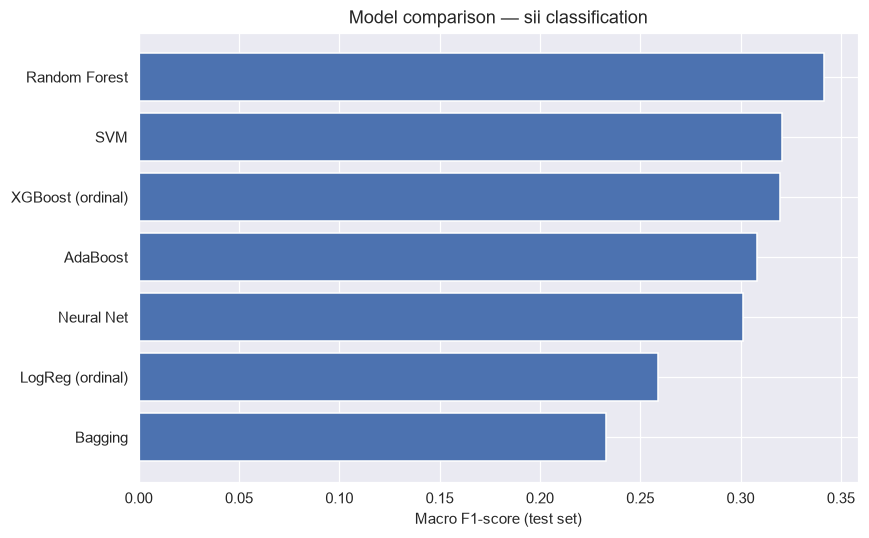

In [15]:
ordered = results_df.sort_values('Macro F1', ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(ordered['Model'], ordered['Macro F1'], color='#4C72B0')
ax.set_xlabel('Macro F1-score (test set)')
ax.set_title('Model comparison — sii classification')
plt.tight_layout(); plt.savefig(OUT_DIR + 'fig23_model_comparison_macrof1.png', dpi=110); plt.show()

## 2.15 — Random Forest Feature Importance (Figure 2.5)

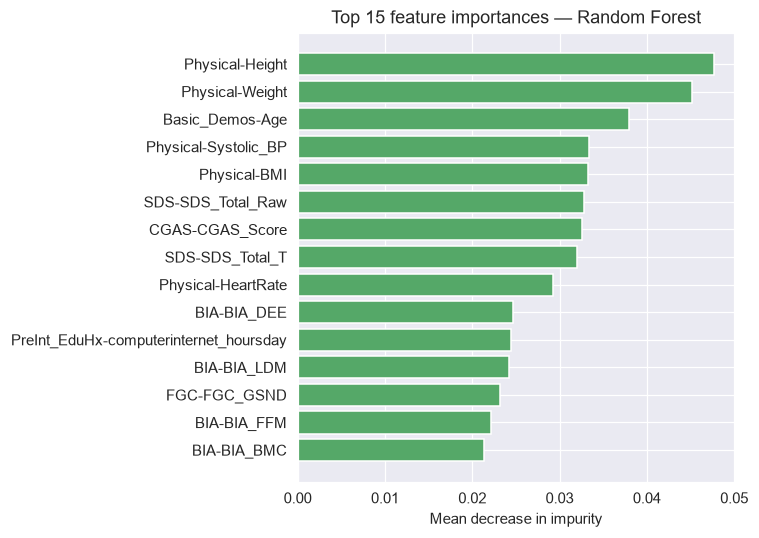

In [16]:
importances = pd.Series(search_rf.best_estimator_.feature_importances_,
                         index=X_train.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(importances.index[::-1], importances.values[::-1], color='#55A868')
ax.set_title('Top 15 feature importances — Random Forest')
ax.set_xlabel('Mean decrease in impurity')
plt.tight_layout(); plt.savefig(OUT_DIR + 'fig25_rf_feature_importance.png', dpi=110); plt.show()

## 2.16 — ROC Curves One-vs-Rest (Figure 2.6)

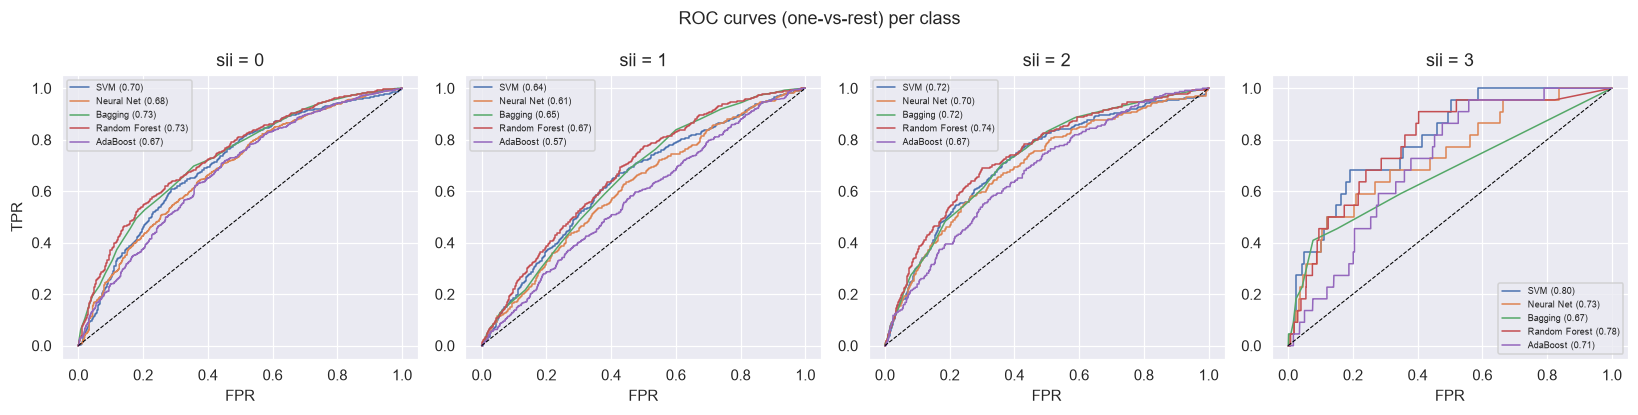

In [17]:
y_test_bin4 = label_binarize(y_test, classes=[0,1,2,3])
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#9467BD']

for cls in range(4):
    ax = axes[cls]
    for (name, res), color in zip(models_res.items(), colors):
        fpr, tpr, _ = roc_curve(y_test_bin4[:, cls], res['proba'][:, cls])
        auc = roc_auc_score(y_test_bin4[:, cls], res['proba'][:, cls])
        ax.plot(fpr, tpr, label=f'{name} ({auc:.2f})', linewidth=1, color=color)
    ax.plot([0,1],[0,1],'k--', linewidth=0.7)
    ax.set_title(f'sii = {cls}'); ax.set_xlabel('FPR')
    if cls == 0: ax.set_ylabel('TPR')
    ax.legend(fontsize=6)
plt.suptitle('ROC curves (one-vs-rest) per class')
plt.tight_layout(); plt.savefig(OUT_DIR + 'fig26_roc_all_models.png', dpi=110); plt.show()

---
## Part B — Advanced Regression

### Target: CGAS Score
**CGAS-CGAS_Score** (Children's Global Assessment Scale, 0–100) is a continuous measure of psychological functioning.  
It was the 3rd-highest SHAP predictor of `sii` — regressing on it tests whether physical/lifestyle features can predict psychological wellbeing.

**Data prep:** Remove rows where CGAS > 100 (data entry errors, including a value of 999).

## 2.17 — Regression Data Preparation

In [18]:
X_tr_reg = X_train.copy(); y_tr_reg = pd.read_csv(OUT_DIR + 'y_train.csv')['sii']

# Reload originals to have CGAS
X_raw_train = pd.read_csv(OUT_DIR + 'X_train_clean.csv')
X_raw_test  = pd.read_csv(OUT_DIR + 'X_test_processed.csv')
y_cgas_train_src = X_raw_train['CGAS-CGAS_Score'].copy()
y_cgas_test_src  = X_raw_test['CGAS-CGAS_Score'].copy()

# Filter out CGAS > 100 (data errors, incl. value 999)
mask_tr = y_cgas_train_src <= 100
mask_te = y_cgas_test_src  <= 100

X_train_reg = X_raw_train[mask_tr].drop(columns=['CGAS-CGAS_Score']).reset_index(drop=True)
y_train_reg = y_cgas_train_src[mask_tr].reset_index(drop=True)
X_test_reg  = X_raw_test[mask_te].drop(columns=['CGAS-CGAS_Score']).reset_index(drop=True)
y_test_reg  = y_cgas_test_src[mask_te].reset_index(drop=True)

print(f"Train: {X_train_reg.shape}  |  Test: {X_test_reg.shape}")
print(f"CGAS mean = {y_train_reg.mean():.2f}  |  std = {y_train_reg.std():.2f}")

# Save for reference
X_train_reg.to_csv(OUT_DIR + 'X_train_reg.csv', index=False)
X_test_reg.to_csv( OUT_DIR + 'X_test_reg.csv',  index=False)
y_train_reg.to_csv(OUT_DIR + 'y_train_reg.csv', index=False)
y_test_reg.to_csv( OUT_DIR + 'y_test_reg.csv',  index=False)

Train: (5854, 106)  |  Test: (2113, 106)
CGAS mean = 65.37  |  std = 8.52


## 2.18 — CGAS Target Distribution (Figure 2.7)

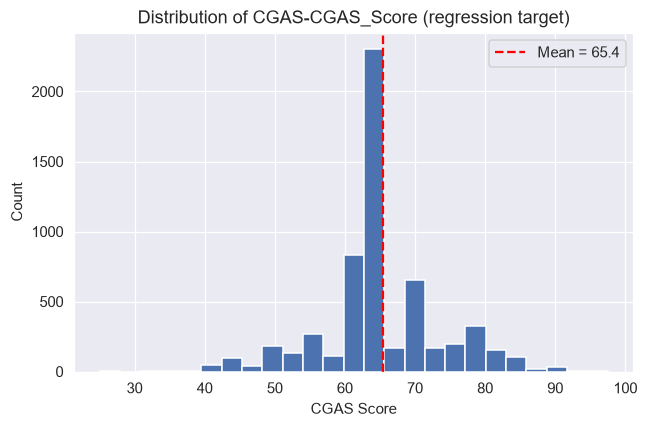

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(y_train_reg, bins=25, color='#4C72B0', edgecolor='white')
ax.axvline(y_train_reg.mean(), color='red', linestyle='--',
           label=f'Mean = {y_train_reg.mean():.1f}')
ax.set_xlabel('CGAS Score'); ax.set_ylabel('Count')
ax.set_title('Distribution of CGAS-CGAS_Score (regression target)')
ax.legend()
plt.tight_layout(); plt.savefig(OUT_DIR + 'fig27_cgas_distribution.png', dpi=110); plt.show()

## 2.19 — XGBoost Regressor with Hyperparameter Tuning

In [20]:
t0 = time.time()
param_dist_xgbr = {
    'n_estimators':     [200, 400],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.02, 0.05, 0.1],
    'subsample':        [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0],
    'reg_lambda':       [1, 2, 5],
}
search_xgbr = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_dist_xgbr, n_iter=8, cv=3, scoring='r2',
    random_state=RANDOM_STATE, n_jobs=-1
)
search_xgbr.fit(X_train_reg, y_train_reg)
print(f"XGBReg done in {time.time()-t0:.1f}s")
print(f"Best: {search_xgbr.best_params_}  |  CV R² = {search_xgbr.best_score_:.3f}")

pred_xgbr = search_xgbr.best_estimator_.predict(X_test_reg)
mse_x = mean_squared_error(y_test_reg, pred_xgbr)
mae_x = mean_absolute_error(y_test_reg, pred_xgbr)
r2_x  = r2_score(y_test_reg, pred_xgbr)
print(f"Test → MSE={mse_x:.2f}  MAE={mae_x:.2f}  R²={r2_x:.3f}")

joblib.dump({'model': search_xgbr.best_estimator_, 'pred': pred_xgbr,
             'best_params': search_xgbr.best_params_, 'cv_r2': search_xgbr.best_score_,
             'mse': mse_x, 'mae': mae_x, 'r2': r2_x}, OUT_DIR + 'm2_reg_xgb.pkl')

XGBReg done in 11.7s
Best: {'subsample': 1.0, 'reg_lambda': 2, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.02, 'colsample_bytree': 1.0}  |  CV R² = 0.019
Test → MSE=75.67  MAE=5.95  R²=0.030


['../outputs/m2_reg_xgb.pkl']

## 2.20 — Random Forest Regressor with Hyperparameter Tuning

In [21]:
t0 = time.time()
param_dist_rfr = {
    'n_estimators':     [200, 300],
    'max_depth':        [10, 20, None],
    'max_features':     [0.3, 0.5, 'sqrt'],
    'min_samples_leaf': [2, 5, 10],
}
search_rfr = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_dist_rfr, n_iter=8, cv=3, scoring='r2',
    random_state=RANDOM_STATE, n_jobs=-1
)
search_rfr.fit(X_train_reg, y_train_reg)
print(f"RFReg done in {time.time()-t0:.1f}s")
print(f"Best: {search_rfr.best_params_}  |  CV R² = {search_rfr.best_score_:.3f}")

pred_rfr = search_rfr.best_estimator_.predict(X_test_reg)
mse_r = mean_squared_error(y_test_reg, pred_rfr)
mae_r = mean_absolute_error(y_test_reg, pred_rfr)
r2_r  = r2_score(y_test_reg, pred_rfr)
print(f"Test → MSE={mse_r:.2f}  MAE={mae_r:.2f}  R²={r2_r:.3f}")

joblib.dump({'model': search_rfr.best_estimator_, 'pred': pred_rfr,
             'best_params': search_rfr.best_params_, 'cv_r2': search_rfr.best_score_,
             'mse': mse_r, 'mae': mae_r, 'r2': r2_r}, OUT_DIR + 'm2_reg_rf.pkl')

RFReg done in 23.2s
Best: {'n_estimators': 200, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': None}  |  CV R² = 0.029
Test → MSE=75.02  MAE=5.88  R²=0.038


['../outputs/m2_reg_rf.pkl']

## 2.21 — Regression Results: Actual vs Predicted + Residuals (Figure 2.8)

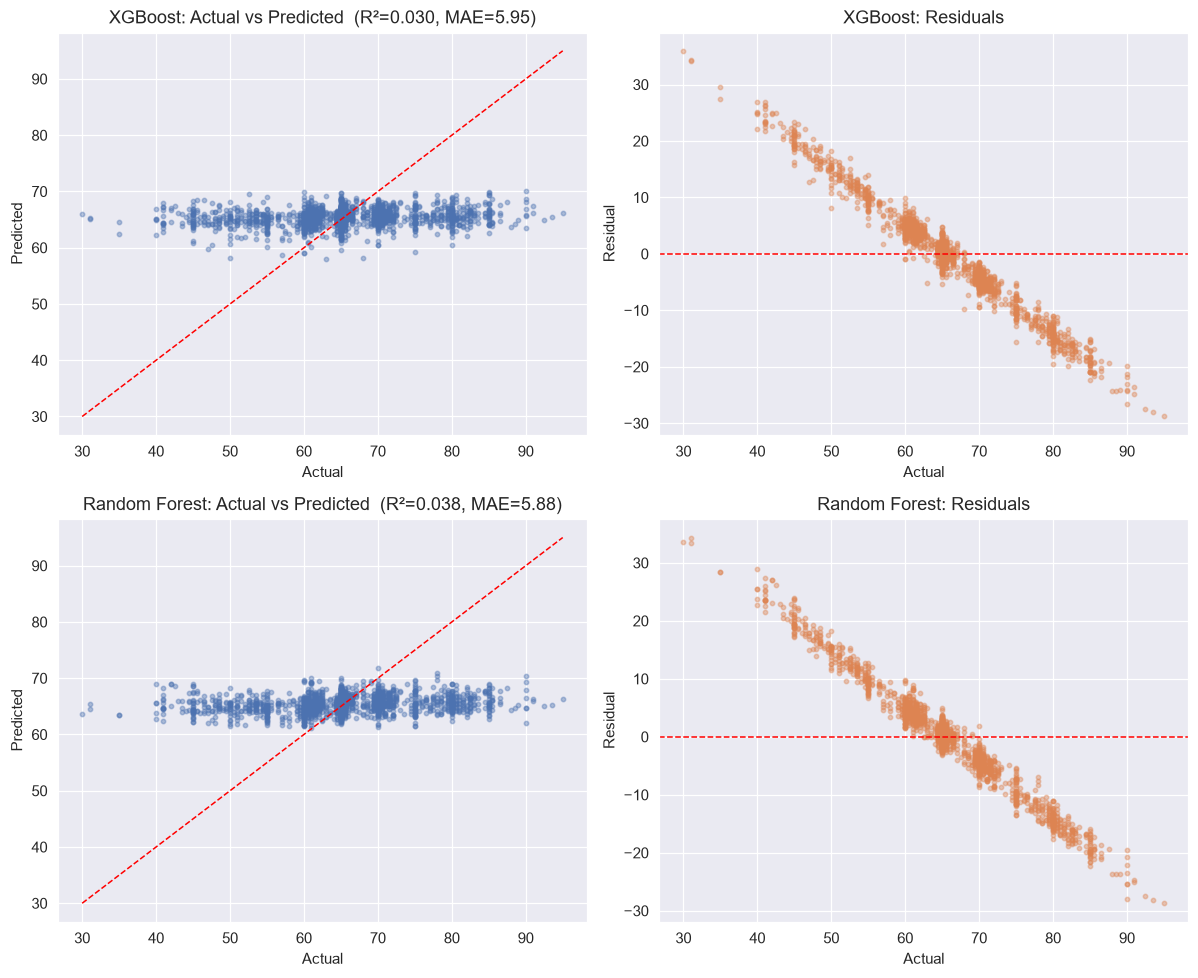

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for row, (pred, name, mse, mae, r2) in enumerate([
    (pred_xgbr, 'XGBoost', mse_x, mae_x, r2_x),
    (pred_rfr,  'Random Forest', mse_r, mae_r, r2_r),
]):
    ax1, ax2 = axes[row]
    lims = [y_test_reg.min(), y_test_reg.max()]
    ax1.scatter(y_test_reg, pred, s=8, alpha=0.4, color='#4C72B0')
    ax1.plot(lims, lims, 'r--', linewidth=1)
    ax1.set_xlabel('Actual'); ax1.set_ylabel('Predicted')
    ax1.set_title(f"{name}: Actual vs Predicted  (R²={r2:.3f}, MAE={mae:.2f})")

    residuals = pred - y_test_reg.values
    ax2.scatter(y_test_reg, residuals, s=8, alpha=0.4, color='#DD8452')
    ax2.axhline(0, color='red', linestyle='--', linewidth=1)
    ax2.set_xlabel('Actual'); ax2.set_ylabel('Residual')
    ax2.set_title(f'{name}: Residuals')

plt.tight_layout(); plt.savefig(OUT_DIR + 'fig28_regression_results.png', dpi=110); plt.show()

## 2.22 — Regression Feature Importances (Figure 2.9)

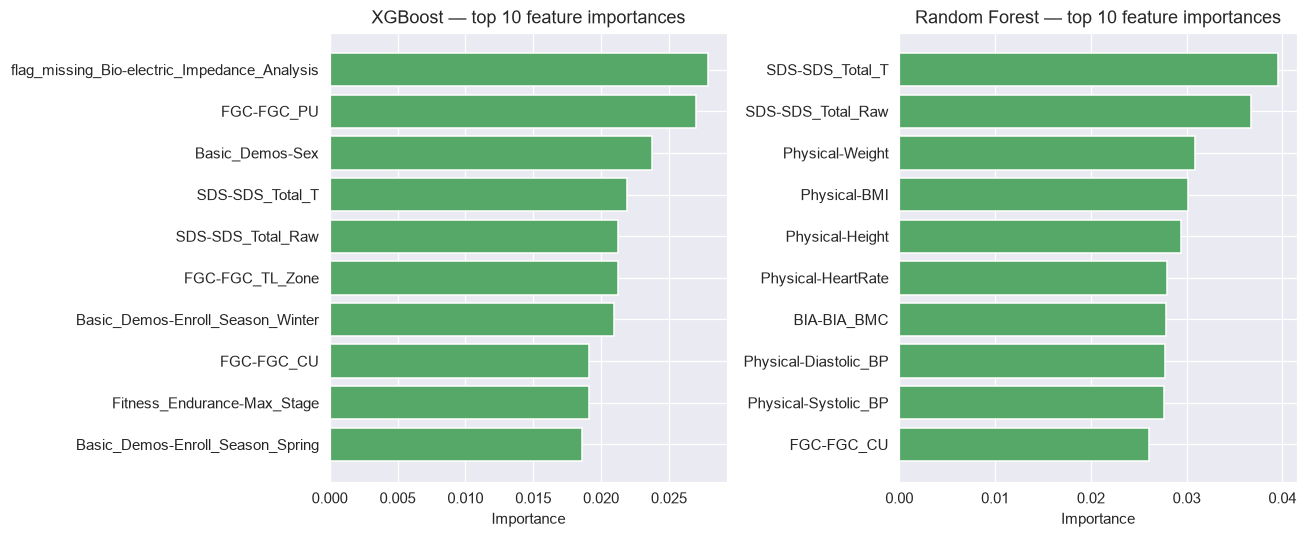

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model, name in [(axes[0], search_xgbr.best_estimator_, 'XGBoost'),
                          (axes[1], search_rfr.best_estimator_, 'Random Forest')]:
    imp = pd.Series(model.feature_importances_,
                    index=X_train_reg.columns).sort_values(ascending=False).head(10)
    ax.barh(imp.index[::-1], imp.values[::-1], color='#55A868')
    ax.set_title(f'{name} — top 10 feature importances'); ax.set_xlabel('Importance')
plt.tight_layout(); plt.savefig(OUT_DIR + 'fig29_regression_feature_importance.png', dpi=110); plt.show()

---
## Part C — Explainability: SHAP Analysis

SHAP is applied to the **XGBoost model for P(sii ≥ 1)** — the most balanced of the three ordinal thresholds (AUC ≈ 0.745).  
TreeExplainer computes exact Shapley values on a 500-instance sample from the test set.

## 2.23 — SHAP Values Computation

In [24]:
xgb_models = joblib.load(OUT_DIR + 'xgb_models.pkl')
model_shap  = xgb_models[1]   # sii >= 1

rng        = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_test), size=min(500, len(X_test)), replace=False)
X_sample   = X_test.iloc[sample_idx].reset_index(drop=True)

explainer   = shap.TreeExplainer(model_shap)
shap_values = explainer(X_sample)
print(f"SHAP values computed for {len(X_sample)} test instances.")

SHAP values computed for 500 test instances.


## 2.24 — SHAP Beeswarm Plot (Figure 2.10)

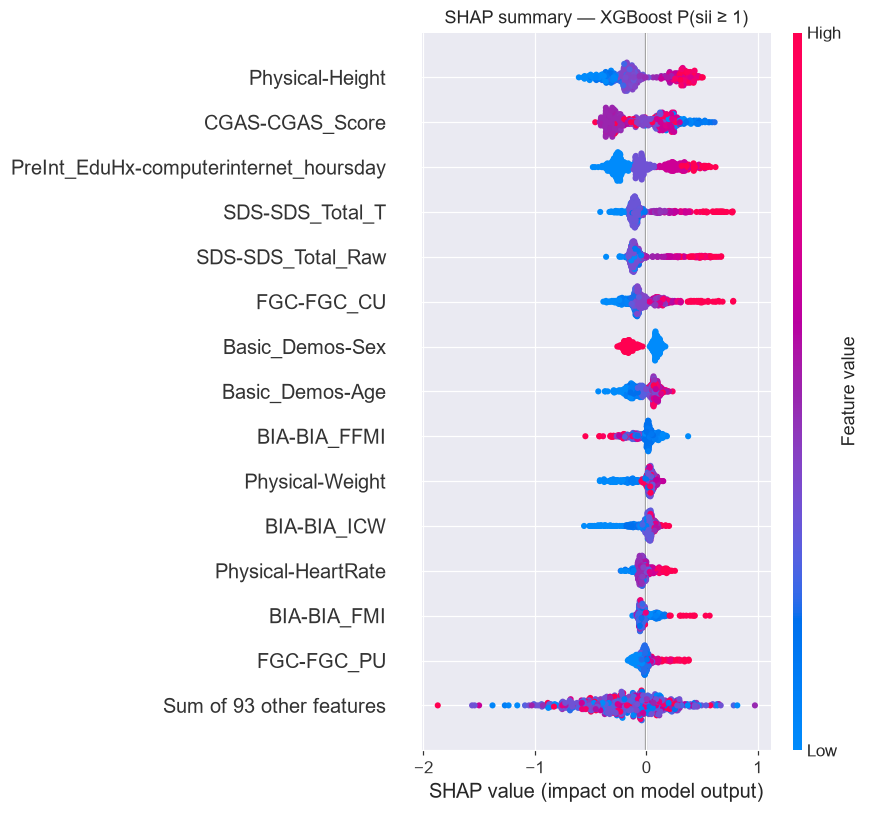

In [25]:
plt.figure(figsize=(8, 6))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title('SHAP summary — XGBoost P(sii ≥ 1)')
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig12_shap_beeswarm.png', dpi=110, bbox_inches='tight')
plt.show()

## 2.25 — SHAP Bar Plot (Figure 2.11)

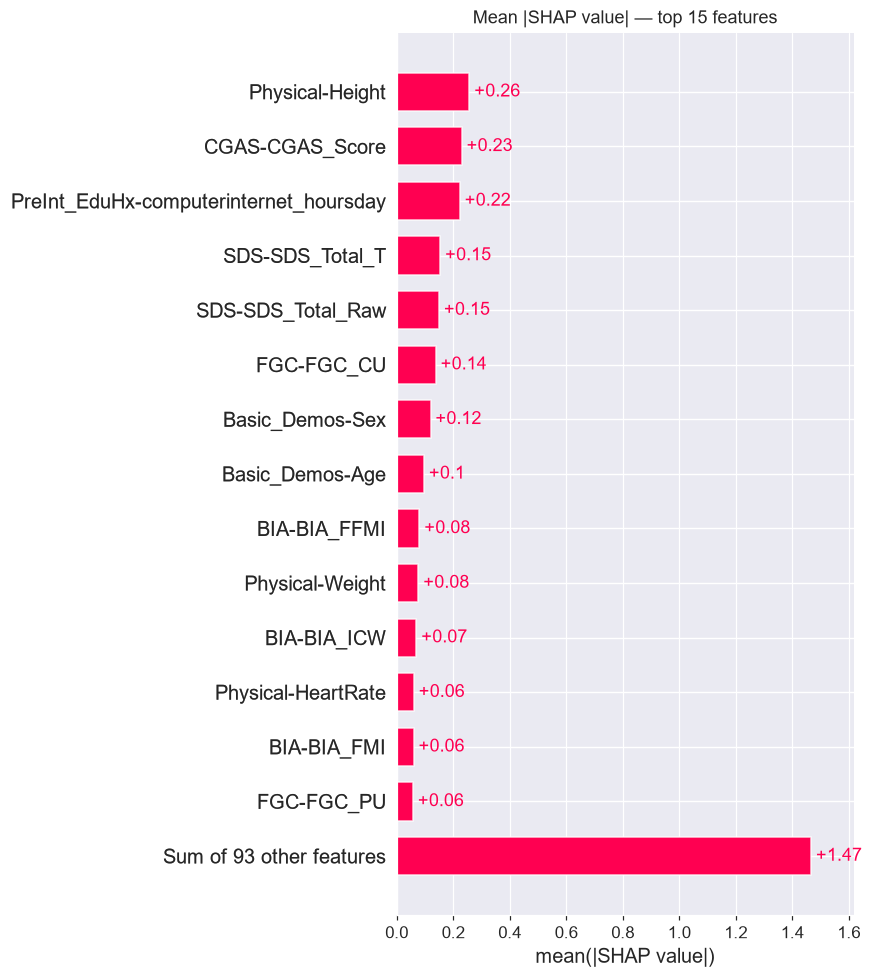

In [26]:
plt.figure(figsize=(8, 6))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title('Mean |SHAP value| — top 15 features')
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig13_shap_bar.png', dpi=110, bbox_inches='tight')
plt.show()

## 2.26 — SHAP Feature Ranking Table

In [27]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_shap = (pd.Series(mean_abs_shap, index=X_sample.columns)
              .sort_values(ascending=False)
              .head(10)
              .rename('Mean |SHAP|'))
top_shap.index.name = 'Feature'
top_shap.to_csv(OUT_DIR + 'table_shap_top10.csv')
print(top_shap.round(3).to_string())

Feature
Physical-Height                           0.257
CGAS-CGAS_Score                           0.230
PreInt_EduHx-computerinternet_hoursday    0.224
SDS-SDS_Total_T                           0.154
SDS-SDS_Total_Raw                         0.150
FGC-FGC_CU                                0.138
Basic_Demos-Sex                           0.120
Basic_Demos-Age                           0.097
BIA-BIA_FFMI                              0.081
Physical-Weight                           0.077


In [28]:
print("✅ Module 2 complete. Outputs saved to:", OUT_DIR)
print("Next: run 03_time_series.ipynb")

✅ Module 2 complete. Outputs saved to: ../outputs/
Next: run 03_time_series.ipynb
